### Model Explainability (SHAP)

#### Importing Packages and Data

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import shap
import matplotlib.pyplot as plt

In [19]:
project_root = Path(".").resolve().parent
model_path = project_root / "models" / "random_forest_pipeline.joblib"
features_path = project_root / "data" / "processed" / "london_features.parquet"
figures_dir = project_root / "reports" / "figures"

In [4]:
pipeline = joblib.load(model_path)
df = pd.read_parquet(features_path)

In [5]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [6]:
df

,price,date_of_transfer,postcode,property_type,old_new,duration,district,postcode_district,property_type_ordinal,district_sales_count,log_price,latitude,longitude,london_zone,distance_to_station_km,is_central
0,215000,2025-01-31,E3 2PQ,F,N,L,TOWER HAMLETS,E3,1,530,5.332438,51.530123,-0.016067,2.0,0.414205,1
1,349000,2025-12-22,E17 7LB,F,N,L,WALTHAM FOREST,E17,1,1046,5.542825,51.582287,-0.028159,3.0,0.309116,0
2,540000,2025-12-16,NW4 3PG,S,N,F,BARNET,NW4,3,212,5.732394,51.577269,-0.230011,3.0,0.671918,0
3,460000,2025-12-15,E2 8FZ,F,N,L,HACKNEY,E2,1,330,5.662758,51.534910,-0.074545,1.0,0.385880,1
4,265000,2025-12-19,E14 9BF,F,N,L,TOWER HAMLETS,E14,1,879,5.423246,51.506823,-0.005480,2.0,0.165213,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72587,393800,2025-06-11,E10 7PE,F,N,L,WALTHAM FOREST,E10,1,450,5.595276,51.567063,-0.030880,3.0,0.403633,0
72588,388000,2025-05-29,RM13 9SN,S,N,F,HAVERING,RM13,3,314,5.588832,51.525933,0.219288,6.0,2.195610,0
72589,358000,2025-06-05,RM3 7DX,T,N,F,HAVERING,RM3,2,402,5.553883,51.602708,0.205338,6.0,2.213750,0
72590,1095000,2025-01-03,E18 2PS,S,N,F,REDBRIDGE,E18,3,226,6.039414,51.599639,0.014872,4.0,1.273380,0


#### Features Setup

In [7]:
NUMERIC_FEATURES = [
    "property_type_ordinal", "district_sales_count", "latitude",
    "longitude", "london_zone", "distance_to_station_km", "is_central",
]
LOW_CATEGORICAL = ["property_type", "old_new", "duration"]
HIGH_CATEGORICAL = ["district", "postcode_district"]
ALL_FEATURES = NUMERIC_FEATURES + LOW_CATEGORICAL + HIGH_CATEGORICAL

In [8]:
X = df[ALL_FEATURES]

In [9]:
X_sample = X.sample(n=1000, random_state=42)

In [10]:
X_sample

,property_type_ordinal,district_sales_count,latitude,longitude,london_zone,distance_to_station_km,is_central,property_type,old_new,duration,district,postcode_district
58084,3,109,51.580014,0.096159,4.0,0.632390,0,S,N,F,REDBRIDGE,IG2
29210,1,248,51.411600,-0.280925,5.0,0.229559,0,F,N,L,KINGSTON UPON THAMES,KT1
26805,2,375,51.399110,-0.126632,3.0,1.368180,0,T,N,F,MERTON,CR4
64103,1,505,51.478383,-0.009487,2.0,0.268088,1,F,N,L,GREENWICH,SE10
51111,2,396,51.650885,-0.219079,5.0,1.719960,0,T,N,F,BARNET,EN5
...,...,...,...,...,...,...,...,...,...,...,...,...
10035,3,226,51.597368,0.018843,4.0,0.901214,0,S,N,F,REDBRIDGE,E18
19573,2,1046,51.575425,-0.031876,3.0,0.579561,0,T,N,F,WALTHAM FOREST,E17
20882,3,256,51.635154,-0.123641,4.0,0.420019,0,S,N,F,ENFIELD,N14
18937,1,238,51.546386,-0.372855,5.0,0.366383,0,F,N,L,EALING,UB5


In [11]:
preprocessor = pipeline.named_steps["prep"]
rf_model = pipeline.named_steps["model"]

In [12]:
X_sample_transformed = preprocessor.transform(X_sample)

In [13]:
feature_names = preprocessor.get_feature_names_out()

In [14]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample_transformed)

In [15]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

In [17]:
print("Global Feature Importance (mean |SHAP|)")
print(importance_df.to_string(index=False))

Global Feature Importance (mean |SHAP|)
                    feature  mean_abs_shap
        low_cat__duration_L       0.101421
high_cat__postcode_district       0.088322
           num__london_zone       0.039699
 num__property_type_ordinal       0.017426
        low_cat__duration_F       0.015454
             num__longitude       0.015274
              num__latitude       0.014046
         high_cat__district       0.010425
num__distance_to_station_km       0.008072
   low_cat__property_type_D       0.006086
            num__is_central       0.005698
   low_cat__property_type_F       0.005265
  num__district_sales_count       0.004657
   low_cat__property_type_S       0.004161
         low_cat__old_new_N       0.003744
         low_cat__old_new_Y       0.003174
   low_cat__property_type_T       0.002197


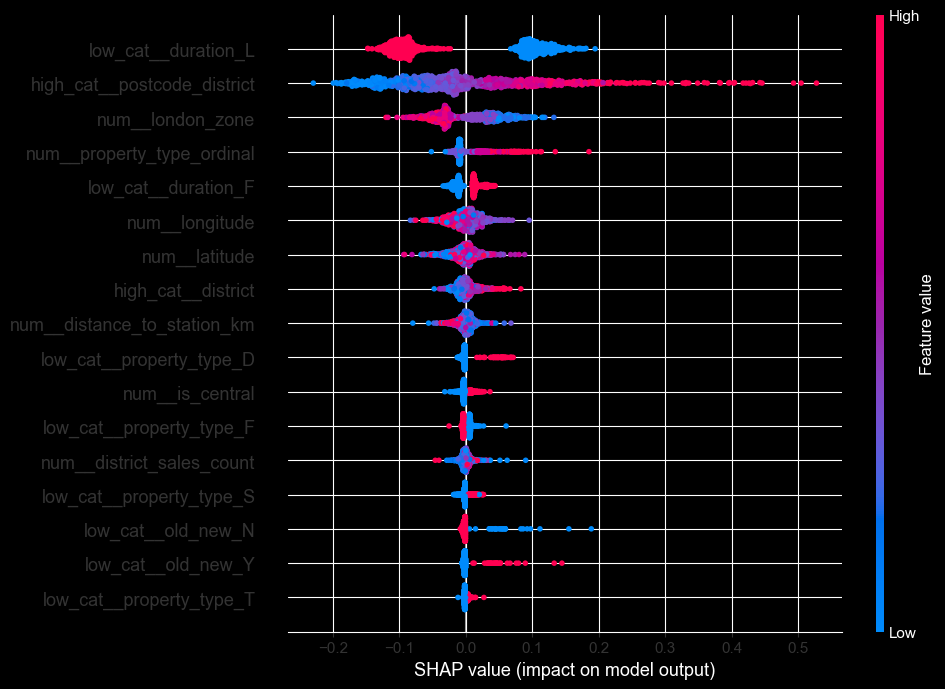

<Figure size 640x480 with 0 Axes>

In [20]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_sample_transformed,
    feature_names=feature_names,
    plot_size=(10, 7),
)
plt.tight_layout()
save_path = figures_dir / "07_shap_summary.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")

In [24]:
idx = 1
property_features = X_sample.iloc[idx]
actual_log_price = df.loc[X_sample.index[idx], "log_price"]
predicted_log_price = pipeline.predict(X_sample.iloc[[idx]])[0]


print(f"\nProperty attributes:")
print(property_features.to_string())
print(f"\nActual price:    £{10 ** actual_log_price:,.0f}")
print(f"Predicted price: £{10 ** predicted_log_price:,.0f}")

contributions = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values[idx],
}).sort_values("shap_value", key=np.abs, ascending=False).head(8)

print(f"\nTop 8 feature contributions (in log-price units):")
print(contributions.to_string(index=False))


Property attributes:
property_type_ordinal                        1
district_sales_count                       248
latitude                               51.4116
longitude                            -0.280925
london_zone                                5.0
distance_to_station_km                0.229559
is_central                                   0
property_type                                F
old_new                                      N
duration                                     L
district                  KINGSTON UPON THAMES
postcode_district                          KT1

Actual price:    £380,000
Predicted price: £388,565

Top 8 feature contributions (in log-price units):
                   feature  shap_value
       low_cat__duration_L   -0.098389
          num__london_zone   -0.020612
        high_cat__district    0.019100
       low_cat__duration_F   -0.013549
num__property_type_ordinal   -0.009791
             num__latitude   -0.008430
            num__longitude   -0.00718

#### SHAP Interpretation: Key Findings

SHAP analysis on a 1,000-property sample identified these as the strongest
drivers of the model's price predictions:

Leasehold/Freehold status. In London, tenure strongly proxies property type (leasehold = flat, freehold = house) and shows the value of outright land ownership.

Postcode district(target-encoded): location is the second strongest signal, finer than borough alone.

London transport zone: central zones command clear premiums.

Five of the top eight features are geographic.

#### Limitations

##### No Property Size and Structural Attributes

HM Land Registry Price Paid Data records transactions, not property
characteristics. The model has no access to floor area, bedroom/bathroom
count, condition, floor level, outdoor space, parking, or remaining lease
length. Two physically very different properties, for example a studio flat and a
large five bedroom penthouse in the same postcode with the same type and tenure receive
identical predictions, because the model cannot observe the difference.

The model is tained on 2025 transactions only and captures the 2025 price
structure but has no concept of market trend and should not be used for
multi-year forecasting.